In [16]:
import sys
from pathlib import Path
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score

# Setup paths
# When running from Preprocessing/src, parents[1] gives IT3212 root
ROOT = Path().resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data" / "facial_emotion_recognition"
SUPPORTED_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif", ".webp"}
RESIZE_SHAPE = (256, 256)

print(f"ROOT: {ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")


ROOT: C:\Users\nicos\lokaleprosjekter\GitHub\IT3212
DATA_ROOT: C:\Users\nicos\lokaleprosjekter\GitHub\IT3212\data\facial_emotion_recognition
DATA_ROOT exists: True


In [17]:
def load_images_from_dataset(root: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Load images from facial_emotion_recognition dataset.
    Returns: (images, labels, groups)
    """
    images = []
    labels = []
    groups = []
    
    for person_dir in sorted(root.iterdir()):
        if not person_dir.is_dir():
            continue
        person_id = person_dir.name
        
        for image_path in sorted(person_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in SUPPORTED_SUFFIXES:
                # Read image in grayscale
                img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                
                # Resize to standard shape
                img_resized = cv2.resize(img, RESIZE_SHAPE, interpolation=cv2.INTER_AREA)
                
                images.append(img_resized)
                labels.append(image_path.stem)  # Emotion label (e.g., "Anger", "Happy")
                groups.append(person_id)
    
    if not images:
        raise RuntimeError(f"No images found in {root}")
    
    return np.array(images), np.array(labels), np.array(groups)

print("Loading images...")
X_images, y_labels, groups = load_images_from_dataset(DATA_ROOT)
print(f"Loaded {len(X_images)} images")
print(f"Image shape: {X_images[0].shape}")
print(f"Unique labels: {np.unique(y_labels)}")
print(f"Unique persons: {len(np.unique(groups))}")


Loading images...
Loaded 152 images
Image shape: (256, 256)
Unique labels: ['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']
Unique persons: 19


In [18]:
def split_by_groups(
    X: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    test_size: float = 4 / 19,
    val_size: float = 3 / 15,
    random_state: int = 42,
) -> tuple:
    """Split data by groups (persons) to avoid data leakage."""
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(X, y, groups))
    
    X_train_val = X[train_val_idx]
    y_train_val = y[train_val_idx]
    groups_train_val = groups[train_val_idx]
    
    X_test = X[test_idx]
    y_test = y[test_idx]
    
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(X_train_val, y_train_val, groups_train_val))
    
    X_train = X_train_val[train_idx]
    y_train = y_train_val[train_idx]
    X_val = X_train_val[val_idx]
    y_val = y_train_val[val_idx]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# Flatten images for ML models
X_flat = X_images.reshape(len(X_images), -1)  # (n_samples, height*width)

# Split data
X_train, y_train, X_val, y_val, X_test, y_test = split_by_groups(X_flat, y_labels, groups)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")


Train size: 96
Validation size: 24
Test size: 32


In [19]:
from dataclasses import dataclass

@dataclass
class AblationResult:
    variant: str
    accuracy: float
    train_time: float

def evaluate_logistic_regression(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    max_iter: int = 100,
    random_state: int = 42,
    multi_class: str = 'auto',
) -> tuple[float, float]:
    """
    Train LogisticRegression and return (accuracy, train_time_seconds).
    Uses train+val for training, test for evaluation.
    
    Args:
        multi_class: 'auto', 'ovr' (one-vs-rest for integer encoding), or 'multinomial' (for one-hot style)
    """
    # Combine train and val for final training
    X_train_combined = np.vstack([X_train, X_val])
    y_train_combined = np.concatenate([y_train, y_val])
    
    model = LogisticRegression(max_iter=max_iter, random_state=random_state, n_jobs=-1, multi_class=multi_class)
    
    start = time.perf_counter()
    model.fit(X_train_combined, y_train_combined)
    elapsed = time.perf_counter() - start
    
    accuracy = accuracy_score(y_test, model.predict(X_test))
    
    return accuracy, elapsed


In [20]:
# Initialize results list
results: list[AblationResult] = []

# Label encoder for integer encoding
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_val_int = label_encoder.transform(y_val)
y_test_int = label_encoder.transform(y_test)

print("Encoders prepared")
print(f"Integer labels shape: {y_train_int.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Class names: {label_encoder.classes_}")


Encoders prepared
Integer labels shape: (96,)
Number of classes: 8
Class names: ['Anger' 'Contempt' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [21]:
# Baseline: Raw images with one-hot encoding (no scaling)
print("Testing Baseline: Raw images with one-hot encoding...")
X_train_baseline = X_train.astype(np.float32)  # Keep 0-255 range
X_val_baseline = X_val.astype(np.float32)
X_test_baseline = X_test.astype(np.float32)

# Use multinomial (softmax) for one-hot encoding style
accuracy, elapsed = evaluate_logistic_regression(
    X_train_baseline, y_train_int,  # LR uses integer labels, but multinomial internally
    X_val_baseline, y_val_int,
    X_test_baseline, y_test_int,
    max_iter=100,
    multi_class='multinomial'  # Softmax for one-hot style
)
results.append(AblationResult(variant="Baseline: Raw + One-Hot", accuracy=accuracy, train_time=elapsed))
print(f"Baseline - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")


Testing Baseline: Raw images with one-hot encoding...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline - Accuracy: 0.1562, Time: 8.91s


In [22]:
# V1: Integer/Label encoding, No scaling (0-255)
print("\nTesting V1: Integer encoding, No scaling (0-255)...")
X_train_v1 = X_train.astype(np.float32)  # Keep 0-255 range
X_val_v1 = X_val.astype(np.float32)
X_test_v1 = X_test.astype(np.float32)

# Use one-vs-rest (default) for integer/label encoding
accuracy, elapsed = evaluate_logistic_regression(
    X_train_v1, y_train_int,
    X_val_v1, y_val_int,
    X_test_v1, y_test_int,
    max_iter=100,
    multi_class='ovr'  # One-vs-rest for integer encoding
)
results.append(AblationResult(variant="V1: Integer/Label, No scaling", accuracy=accuracy, train_time=elapsed))
print(f"V1 - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")



Testing V1: Integer encoding, No scaling (0-255)...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


V1 - Accuracy: 0.1562, Time: 4.73s


In [23]:
# V2: One-Hot encoding, No scaling (0-255)
print("\nTesting V2: One-Hot encoding, No scaling (0-255)...")
X_train_v2 = X_train.astype(np.float32)  # Keep 0-255 range
X_val_v2 = X_val.astype(np.float32)
X_test_v2 = X_test.astype(np.float32)

# Use multinomial (softmax) for one-hot encoding style
accuracy, elapsed = evaluate_logistic_regression(
    X_train_v2, y_train_int,
    X_val_v2, y_val_int,
    X_test_v2, y_test_int,
    max_iter=100,
    multi_class='multinomial'  # Softmax for one-hot style
)
results.append(AblationResult(variant="V2: One-Hot, No scaling", accuracy=accuracy, train_time=elapsed))
print(f"V2 - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")



Testing V2: One-Hot encoding, No scaling (0-255)...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


V2 - Accuracy: 0.1562, Time: 7.98s


In [24]:
# V3: One-Hot encoding, MinMax Normalization (0-1)
print("\nTesting V3: One-Hot encoding, MinMax Normalization (0-1)...")
scaler_minmax = MinMaxScaler()
X_train_v3 = scaler_minmax.fit_transform(X_train.astype(np.float32))
X_val_v3 = scaler_minmax.transform(X_val.astype(np.float32))
X_test_v3 = scaler_minmax.transform(X_test.astype(np.float32))

# Use multinomial (softmax) for one-hot encoding style
accuracy, elapsed = evaluate_logistic_regression(
    X_train_v3, y_train_int,
    X_val_v3, y_val_int,
    X_test_v3, y_test_int,
    max_iter=100,
    multi_class='multinomial'  # Softmax for one-hot style
)
results.append(AblationResult(variant="V3: One-Hot, MinMax (0-1)", accuracy=accuracy, train_time=elapsed))
print(f"V3 - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")



Testing V3: One-Hot encoding, MinMax Normalization (0-1)...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


V3 - Accuracy: 0.2500, Time: 9.17s


In [25]:
# V4: One-Hot encoding, Standardization (Z-score)
print("\nTesting V4: One-Hot encoding, Standardization (Z-score)...")
scaler_std = StandardScaler()
X_train_v4 = scaler_std.fit_transform(X_train.astype(np.float32))
X_val_v4 = scaler_std.transform(X_val.astype(np.float32))
X_test_v4 = scaler_std.transform(X_test.astype(np.float32))

# Use multinomial (softmax) for one-hot encoding style
accuracy, elapsed = evaluate_logistic_regression(
    X_train_v4, y_train_int,
    X_val_v4, y_val_int,
    X_test_v4, y_test_int,
    max_iter=100,
    multi_class='multinomial'  # Softmax for one-hot style
)
results.append(AblationResult(variant="V4: One-Hot, Standardization", accuracy=accuracy, train_time=elapsed))
print(f"V4 - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")



Testing V4: One-Hot encoding, Standardization (Z-score)...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


V4 - Accuracy: 0.2500, Time: 5.90s


In [26]:
# V5: Integer/Label encoding, MinMax Normalization (0-1)
print("\nTesting V5: Integer encoding, MinMax Normalization (0-1)...")
scaler_minmax_v5 = MinMaxScaler()
X_train_v5 = scaler_minmax_v5.fit_transform(X_train.astype(np.float32))
X_val_v5 = scaler_minmax_v5.transform(X_val.astype(np.float32))
X_test_v5 = scaler_minmax_v5.transform(X_test.astype(np.float32))

# Use one-vs-rest for integer/label encoding
accuracy, elapsed = evaluate_logistic_regression(
    X_train_v5, y_train_int,
    X_val_v5, y_val_int,
    X_test_v5, y_test_int,
    max_iter=100,
    multi_class='ovr'  # One-vs-rest for integer encoding
)
results.append(AblationResult(variant="V5: Integer/Label, MinMax (0-1)", accuracy=accuracy, train_time=elapsed))
print(f"V5 - Accuracy: {accuracy:.4f}, Time: {elapsed:.2f}s")



Testing V5: Integer encoding, MinMax Normalization (0-1)...


c:\Users\nicos\lokaleprosjekter\GitHub\IT3212\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


V5 - Accuracy: 0.2188, Time: 4.72s


In [27]:
# Print results table
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
print(f"{'Variant':<40} {'Accuracy':>12} {'Time (s)':>12}")
print("-"*70)
for result in results:
    print(f"{result.variant:<40} {result.accuracy*100:>10.2f}% {result.train_time:>12.2f}")
print("="*70)



ABLATION STUDY RESULTS
Variant                                      Accuracy     Time (s)
----------------------------------------------------------------------
Baseline: Raw + One-Hot                       15.62%         8.91
V1: Integer/Label, No scaling                 15.62%         4.73
V2: One-Hot, No scaling                       15.62%         7.98
V3: One-Hot, MinMax (0-1)                     25.00%         9.17
V4: One-Hot, Standardization                  25.00%         5.90
V5: Integer/Label, MinMax (0-1)               21.88%         4.72


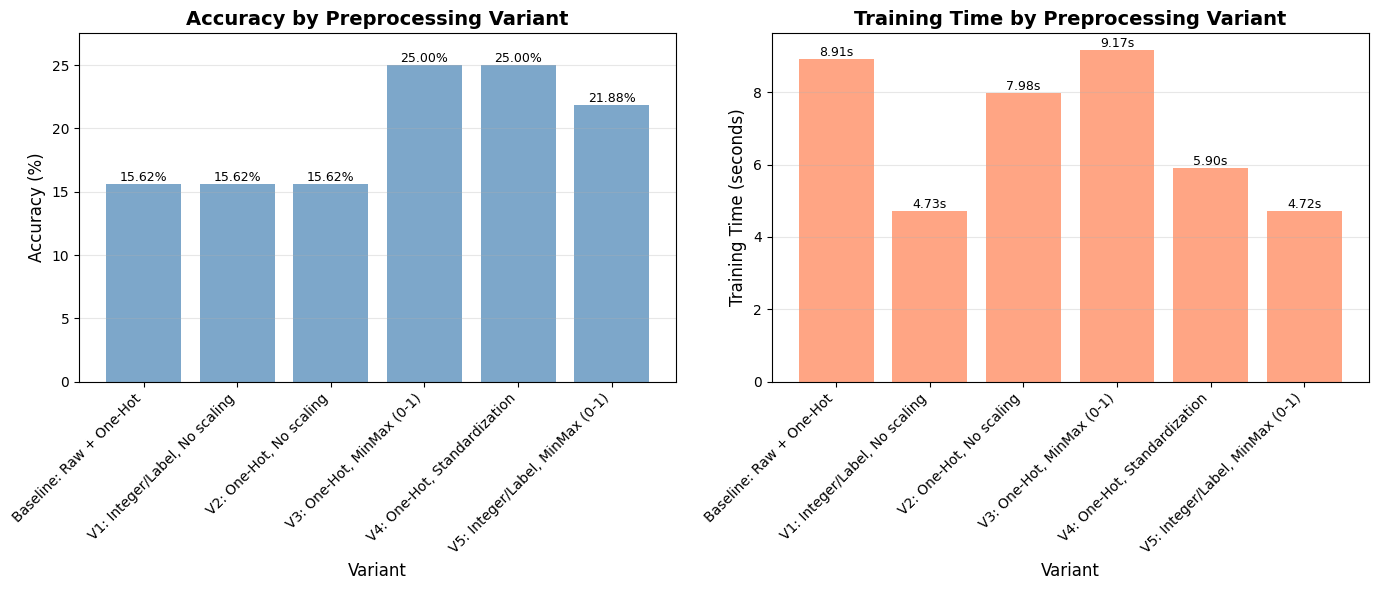

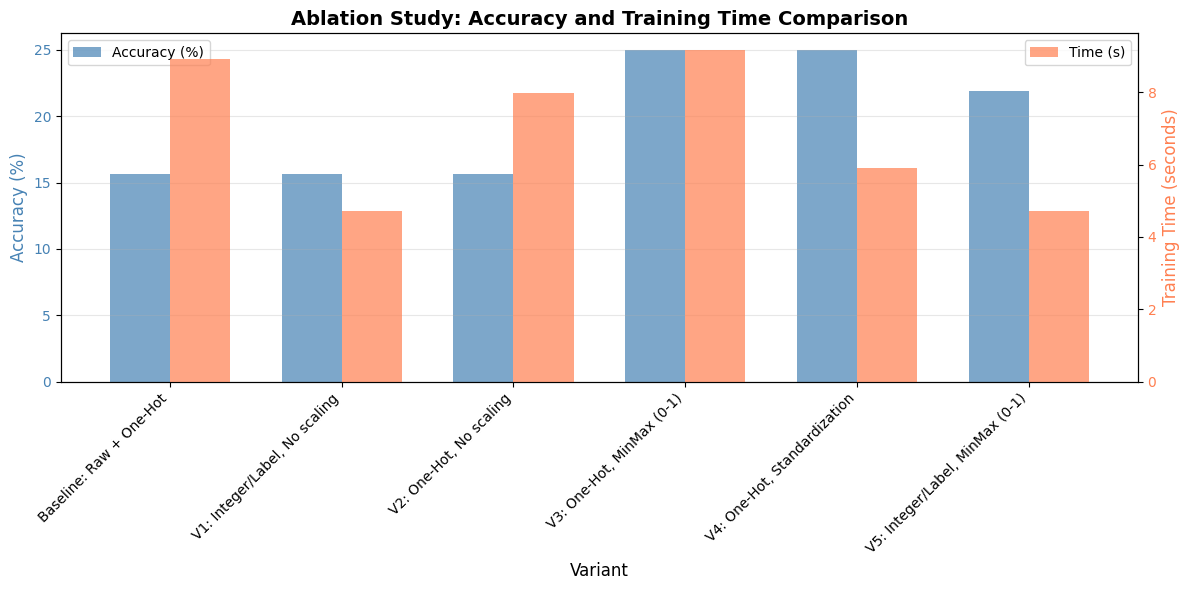


Ablation plots displayed!


In [28]:
# Create ablation plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

variants = [r.variant for r in results]
accuracies = [r.accuracy * 100 for r in results]
times = [r.train_time for r in results]

# Accuracy plot
bars1 = ax1.bar(range(len(variants)), accuracies, color='steelblue', alpha=0.7)
ax1.set_xlabel('Variant', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy by Preprocessing Variant', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(variants)))
ax1.set_xticklabels(variants, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, max(accuracies) * 1.1])

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars1, accuracies)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=9)

# Time plot
bars2 = ax2.bar(range(len(variants)), times, color='coral', alpha=0.7)
ax2.set_xlabel('Variant', fontsize=12)
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.set_title('Training Time by Preprocessing Variant', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(variants)))
ax2.set_xticklabels(variants, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, time_val) in enumerate(zip(bars2, times)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.2f}s',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Also create a combined comparison plot
fig2, ax3 = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(variants))
width = 0.35

bars3 = ax3.bar(x_pos - width/2, accuracies, width, label='Accuracy (%)', color='steelblue', alpha=0.7)
ax3_twin = ax3.twinx()
bars4 = ax3_twin.bar(x_pos + width/2, times, width, label='Time (s)', color='coral', alpha=0.7)

ax3.set_xlabel('Variant', fontsize=12)
ax3.set_ylabel('Accuracy (%)', fontsize=12, color='steelblue')
ax3_twin.set_ylabel('Training Time (seconds)', fontsize=12, color='coral')
ax3.set_title('Ablation Study: Accuracy and Training Time Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(variants, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3_twin.tick_params(axis='y', labelcolor='coral')

# Add legends
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nAblation plots displayed!")


In [29]:
# PCA Variance Analysis
from sklearn.decomposition import PCA

print("Running PCA on images to analyze variance explanation...")

# Use all images (flattened) for PCA
X_all_flat = X_images.reshape(len(X_images), -1).astype(np.float32)

# Normalize to 0-1 range
X_all_normalized = X_all_flat / 255.0

# Center the data (subtract mean)
mean_image = np.mean(X_all_normalized, axis=0)
X_centered = X_all_normalized - mean_image

print(f"Data shape: {X_centered.shape}")
print(f"Number of samples: {X_centered.shape[0]}")
print(f"Number of features (pixels): {X_centered.shape[1]}")

# Fit PCA on all data
# Use min(n_samples, n_features) components
n_components = min(X_centered.shape[0], X_centered.shape[1])
pca = PCA(n_components=n_components)
pca.fit(X_centered)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nPCA fitted with {len(explained_variance)} components")
print(f"First 10 components explain {cumulative_variance[9]*100:.2f}% of variance")
print(f"First 50 components explain {cumulative_variance[49]*100:.2f}% of variance")
print(f"First 100 components explain {cumulative_variance[min(99, len(cumulative_variance)-1)]*100:.2f}% of variance")
print(f"Total variance explained: {cumulative_variance[-1]*100:.2f}%")


Running PCA on images to analyze variance explanation...
Data shape: (152, 65536)
Number of samples: 152
Number of features (pixels): 65536

PCA fitted with 152 components
First 10 components explain 75.25% of variance
First 50 components explain 91.95% of variance
First 100 components explain 97.76% of variance
Total variance explained: 100.00%


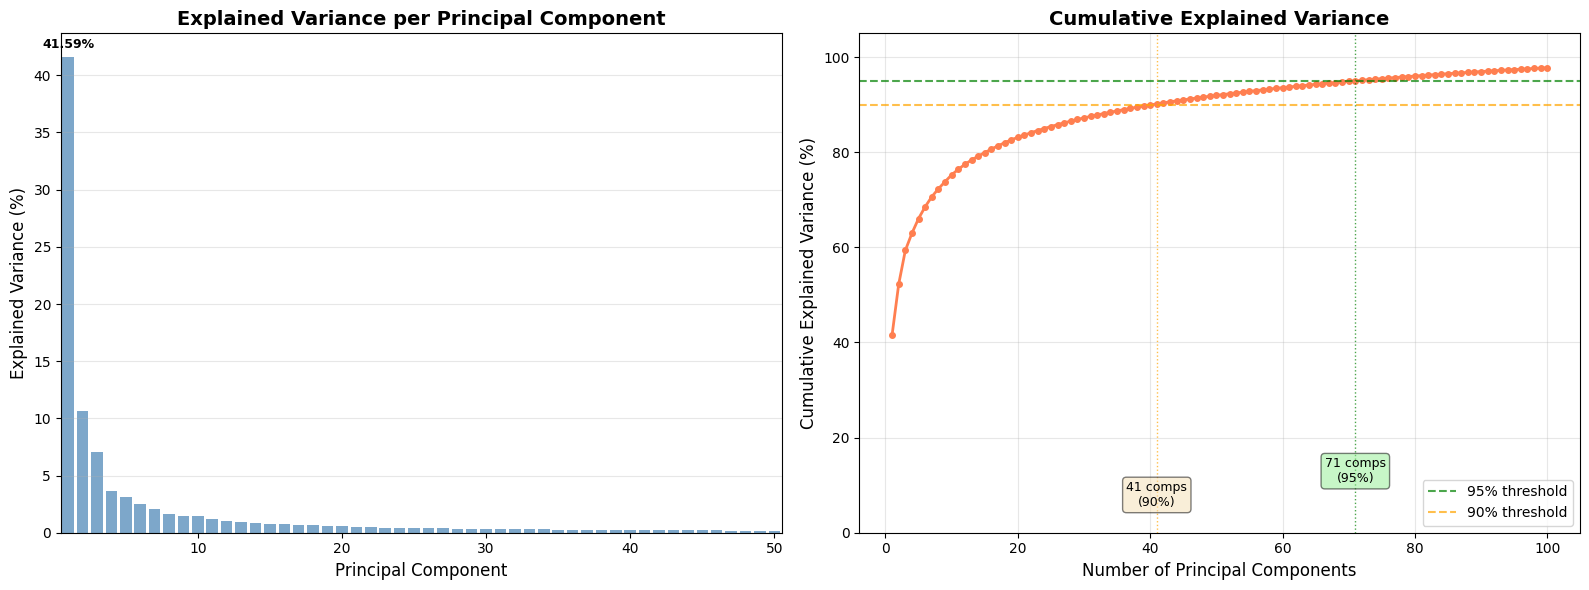


PCA VARIANCE ANALYSIS SUMMARY
Total number of components: 152
First component explains: 41.59% of variance
Top 5 components explain: 66.06% of variance
Top 10 components explain: 75.25% of variance
Components needed for 90% variance: 41
Components needed for 95% variance: 71


In [30]:
# Visualize PCA variance explanation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Explained variance per component (first 50 components)
n_show = min(50, len(explained_variance))
components_to_show = np.arange(1, n_show + 1)

ax1.bar(components_to_show, explained_variance[:n_show] * 100, 
        color='steelblue', alpha=0.7, width=0.8)
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12)
ax1.set_title('Explained Variance per Principal Component', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xlim([0.5, n_show + 0.5])

# Add value for first component
if len(explained_variance) > 0:
    ax1.text(1, explained_variance[0] * 100 + 0.5,
             f'{explained_variance[0]*100:.2f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Cumulative explained variance
n_show_cum = min(100, len(cumulative_variance))
components_cum = np.arange(1, n_show_cum + 1)

ax2.plot(components_cum, cumulative_variance[:n_show_cum] * 100, 
         color='coral', linewidth=2, marker='o', markersize=4)
ax2.axhline(y=95, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='95% threshold')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Principal Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax2.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 105])
ax2.legend(loc='lower right')

# Find number of components for 90% and 95% variance
idx_90 = np.where(cumulative_variance >= 0.90)[0]
idx_95 = np.where(cumulative_variance >= 0.95)[0]

if len(idx_90) > 0:
    n_comp_90 = idx_90[0] + 1
    ax2.axvline(x=n_comp_90, color='orange', linestyle=':', linewidth=1, alpha=0.7)
    ax2.text(n_comp_90, 5, f'{n_comp_90} comps\n(90%)', 
             ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

if len(idx_95) > 0:
    n_comp_95 = idx_95[0] + 1
    ax2.axvline(x=n_comp_95, color='green', linestyle=':', linewidth=1, alpha=0.7)
    ax2.text(n_comp_95, 10, f'{n_comp_95} comps\n(95%)', 
             ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("PCA VARIANCE ANALYSIS SUMMARY")
print("="*70)
print(f"Total number of components: {len(explained_variance)}")
print(f"First component explains: {explained_variance[0]*100:.2f}% of variance")
print(f"Top 5 components explain: {cumulative_variance[4]*100:.2f}% of variance")
print(f"Top 10 components explain: {cumulative_variance[9]*100:.2f}% of variance")
if len(idx_90) > 0:
    print(f"Components needed for 90% variance: {n_comp_90}")
if len(idx_95) > 0:
    print(f"Components needed for 95% variance: {n_comp_95}")
print("="*70)
